In [30]:
library(tidyverse)
library(glue)

In [31]:
sessionInfo()

R version 4.2.1 (2022-06-23)
Platform: x86_64-apple-darwin13.4.0 (64-bit)
Running under: macOS Big Sur ... 10.16

Matrix products: default
BLAS/LAPACK: /Users/joonklaps/opt/anaconda3/lib/libopenblasp-r0.3.20.dylib

locale:
[1] C/C.UTF-8/C/C/C/C

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] glue_1.7.0      lubridate_1.9.3 forcats_1.0.0   stringr_1.5.1  
 [5] dplyr_1.1.4     purrr_1.0.2     readr_2.1.5     tidyr_1.3.1    
 [9] tibble_3.2.1    ggplot2_3.5.2   tidyverse_2.0.0

loaded via a namespace (and not attached):
 [1] pillar_1.10.2      compiler_4.2.1     RColorBrewer_1.1-3 base64enc_0.1-3   
 [5] tools_4.2.1        bit_4.0.5          digest_0.6.36      uuid_1.2-0        
 [9] timechange_0.3.0   jsonlite_1.8.8     evaluate_1.0.3     lifecycle_1.0.4   
[13] gtable_0.3.6       pkgconfig_2.0.3    rlang_1.1.4        IRdisplay_1.1     
[17] cli_3.6.3          parallel_4.2.1     IRkernel_1.3.2     fastmap_1

Reference similarities to MN090277.1:

-   MN090277.1: 100% (self)
-   MN090188.1: 98.7% similarity
-   MN090240.1: 96.7% similarity
-   MZ766668.1: 83.5% similarity


In [32]:
got_df <- data.frame(
    got = c("Eddard", "Catelyn", "Robb", "Jon", "Sansa", "Arya", "Daenerys", "Tyrion", "Jaime", "Bran", "Rickon", "Theon", "Jorah"),
    input_genomes = c(
        "MN090188.1, MN090277.1",
        "MN090188.1, MN090277.1",
        "MN090188.1, MN090277.1",
        "MN090240.1, MN090277.1",
        "MN090240.1, MN090277.1",
        "MN090240.1, MN090277.1",
        "MZ766668.1, MN090277.1",
        "MZ766668.1, MN090277.1",
        "MZ766668.1, MN090277.1",
        "MN090277.1",
        "MN090188.1",
        "MN090240.1",
        "MZ766668.1"
    )
)

iden_df <- data.frame(
    ref = c("MN090277.1", "MN090188.1", "MN090240.1", "MZ766668.1"),
    similarity = c(1, 0.987, 0.967, 0.835)
)


In [ ]:
galn <- read_tsv("./data-preparation/global-alignment/global_alignment_stats.tsv")%>%
  mutate(got = str_extract(seq1_id, "^[^_]+"),
    dist_cons_to_ref = case_when(
      seq2_id == "MN090277.1" ~ 1,
      seq2_id == "MN090188.1" ~ 0.987,
      seq2_id == "MN090240.1" ~ 0.967,
      seq2_id == "MZ766668.1" ~ 0.955,
      TRUE ~ NA_real_
    )
  )%>%
  left_join(got_df, by="got")

Rows: 39 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (2): seq1_id, seq2_id
dbl (11): alignment_length, comparable_sites, matches, mismatches, mismatch_...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [35]:
best_match <- galn%>%group_by(seq1_id)%>%
  arrange(desc(comparable_sites))%>%
  slice(1)%>%
  select(seq1_id, best_match=seq2_id)

In [41]:
selection <- galn%>%
    merge(best_match, by="seq1_id")%>%
    filter(seq2_id == "MN090277.1")

In [44]:
nonmixture_samples <- c("Bran", "Rickon", "Theon", "Jorah")
nonmix<- selection%>%filter(got %in% nonmixture_samples)

Warning message in geom_vline(data = nonmix, inherit.aes = FALSE, aes(xintercept = matches/alignment_length), :
“Ignoring unknown parameters: `inherit.aes`”


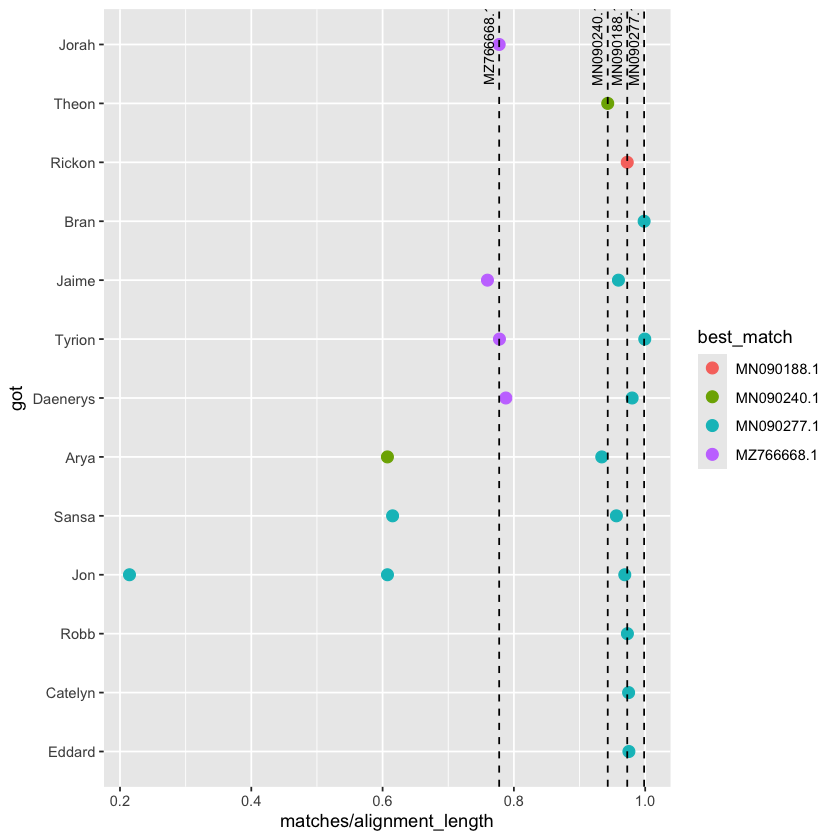

In [45]:
selection %>%
  # filter(! got %in% nonmixture_samples) %>%
  mutate(got = factor(got, levels=got_df$got)) %>%
  ggplot(aes(y=got, x=matches/alignment_length, color=best_match))+
  geom_point(size=3)+
  geom_vline(data=nonmix, inherit.aes=FALSE, aes(xintercept=matches/alignment_length), linetype="dashed")+
  geom_text(data= nonmix, inherit.aes=FALSE, aes(x=matches/alignment_length, label=best_match), y=13, angle=90, vjust=-0.5, size=3)

In [46]:
selection%>%filter(got %in% c("Arya", "Sansa", "Jon"))

seq1_id,seq2_id,alignment_length,comparable_sites,matches,mismatches,mismatch_rate,seq1_length,seq2_length,seq1_gaps,seq2_gaps,seq1_Ns,seq2_Ns,got,dist_cons_to_ref,input_genomes,best_match
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<chr>
Arya_cl55_it2.consensus_bcftools,MN090277.1,12469,7598,7573,1567,0.206238,12402,9232,67,3237,57,0,Arya,1,"MN090240.1, MN090277.1",MN090240.1
Arya_cl56_it2.consensus_bcftools,MN090277.1,9478,9012,8851,199,0.022082,9457,9232,9,246,400,0,Arya,1,"MN090240.1, MN090277.1",MN090277.1
Jon_cl60_it2.consensus_bcftools,MN090277.1,12532,7723,7612,1391,0.180111,12414,9232,118,3300,141,0,Jon,1,"MN090240.1, MN090277.1",MN090277.1
Jon_cl62_it2.consensus_bcftools,MN090277.1,9297,9167,9008,42,0.004582,9274,9232,0,65,221,0,Jon,1,"MN090240.1, MN090277.1",MN090277.1
Jon_cl92_it2.consensus_bcftools,MN090277.1,9700,2080,2080,38,0.018269,2584,9232,7114,468,0,0,Jon,1,"MN090240.1, MN090277.1",MN090277.1
Sansa_cl87_it2.consensus_bcftools,MN090277.1,12511,7702,7697,1421,0.184498,12402,9232,109,3279,23,0,Sansa,1,"MN090240.1, MN090277.1",MN090277.1
Sansa_cl88_it2.consensus_bcftools,MN090277.1,9297,9048,8889,171,0.018899,9284,9232,9,65,221,0,Sansa,1,"MN090240.1, MN090277.1",MN090277.1
